# Assortativity Analysis: VC Syndication Networks

This notebook analyzes the assortativity coefficient for investor communities in venture capital syndication networks.
Assortativity measures the tendency of highly connected nodes to link to other highly connected nodes.

## Setup and Imports

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
from tqdm import tqdm
from scipy import stats
from collections import Counter

# warnings.filterwarnings('ignore')

import sys
import os

sys.path.append('../libs')

# Import custom modules
from libs.data_cleaning import *
from libs.data_extraction import *
from libs.network_analysis import *

plt.style.use('default')
sns.set_palette('husl')

In [ ]:
country = "us"
processed_dir = f'../../data/processed/{country}'
figures_dir = f'../../reports/figures/{country}'

edges_file = f"{processed_dir}/edges.csv"
nodes_file = f"{processed_dir}/nodes.csv"

# Create figures directory if it doesn't exist
os.makedirs(figures_dir, exist_ok=True)

# Time parameters
min_year = 2004
max_year = 2024
cumulative_window = 21

## Load Data

In [3]:
# Load edges and nodes
print("Loading edges and nodes data...")
edges = pd.read_csv(edges_file)
nodes = pd.read_csv(nodes_file)

print(f"Edges shape: {edges.shape}")
print(f"Nodes shape: {nodes.shape}")
print(f"\nEdges columns: {edges.columns.tolist()}")
print(f"Nodes columns: {nodes.columns.tolist()}")

# Display sample data
print(f"\nSample edges:")
print(edges.head())
print(f"\nSample nodes:")
print(nodes.head())

Loading edges and nodes data...
Edges shape: (156481, 24)
Nodes shape: (15347, 7)

Edges columns: ['index', 'investor_name_left', 'investor_name_right', 'announced_year_left', 'announced_year_right', 'org_uuid', 'total_funding_usd', 'total_funding_usd_left', 'total_funding_usd_right', 'year', 'company_country', 'investor_country_left', 'investor_country_right', 'investor_region_left', 'investor_region_right', 'investment_type_left', 'investment_type_right', 'category_left', 'category_right', 'community_left', 'community_right', 'community', 'Source', 'Target']
Nodes columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set']

Sample edges:
   index  investor_name_left         investor_name_right  announced_year_left  \
0      0  Benchmark-series_c              Accel-series_a                 2007   
1      2  Benchmark-series_c    Sequoia Capital-series_a                 2007   
2      3  Benchmark-series_c  Crosslink Capital-series_a                 2007   
3  

## Assortativity Analysis

### Overview

**Assortativity coefficient** measures the preference of nodes to associate with nodes of similar degree:
- **Positive assortativity**: High-degree nodes preferentially connect to other high-degree nodes (assortative mixing)
- **Negative assortativity**: High-degree nodes preferentially connect to low-degree nodes (disassortative mixing)
- **Zero assortativity**: No preference (random mixing)

Range: -1 (perfectly disassortative) to +1 (perfectly assortative)

In [4]:
def calculate_assortativity(edges_df, nodes_df, community_id):
    """
    Calculate assortativity coefficient for a specific community.
    
    Parameters:
    -----------
    edges_df : pd.DataFrame
        DataFrame with columns 'Source', 'Target', 'community'
    nodes_df : pd.DataFrame
        DataFrame with columns 'id', 'community_id'
    community_id : int
        Community ID to analyze
    
    Returns:
    --------
    dict : Contains assortativity coefficient and network metrics
    """
    
    # Filter edges for this community
    community_edges = edges_df[edges_df['community'] == community_id].copy()
    
    if len(community_edges) == 0:
        return None
    
    # Create NetworkX graph
    G = nx.Graph()
    
    # Add edges
    for _, row in community_edges.iterrows():
        G.add_edge(row['Source'], row['Target'])
    
    # Calculate assortativity coefficient
    assortativity = nx.degree_assortativity_coefficient(G)
    
    # Calculate additional metrics
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    
    # Get degree distribution statistics
    degrees = [G.degree(n) for n in G.nodes()]
    mean_degree = np.mean(degrees)
    median_degree = np.median(degrees)
    std_degree = np.std(degrees)
    
    return {
        'community_id': community_id,
        'assortativity': assortativity,
        'num_nodes': num_nodes,
        'num_edges': num_edges,
        'density': density,
        'mean_degree': mean_degree,
        'median_degree': median_degree,
        'std_degree': std_degree
    }


def calculate_assortativity_temporal(edges_df, nodes_df, community_id, min_year, max_year, cumulative_window):
    """
    Calculate assortativity coefficient over time for a specific community.
    
    Parameters:
    -----------
    edges_df : pd.DataFrame
        DataFrame with columns 'Source', 'Target', 'community', 'year'
    nodes_df : pd.DataFrame
        DataFrame with columns 'id', 'community_id'
    community_id : int
        Community ID to analyze
    min_year : int
        Starting year
    max_year : int
        Ending year
    cumulative_window : int
        Window size for cumulative analysis
    
    Returns:
    --------
    list : List of dicts containing yearly assortativity metrics
    """
    
    results = []
    
    for year in range(min_year, max_year + 1):
        # Get cumulative data for the current window
        window_data = edges_df[
            (edges_df['year'] <= year) & 
            (edges_df['year'] >= year - cumulative_window) &
            (edges_df['community'] == community_id)
        ]
        
        if len(window_data) < 3:  # Need at least 3 edges
            results.append({
                'community_id': community_id,
                'year': year,
                'window_start': year - cumulative_window,
                'window_end': year,
                'num_edges': len(window_data),
                'num_nodes': 0,
                'assortativity': np.nan,
                'density': np.nan,
                'mean_degree': np.nan,
                'median_degree': np.nan,
                'std_degree': np.nan
            })
            continue
        
        try:
            # Create NetworkX graph
            G = nx.Graph()
            
            # Add edges
            for _, row in window_data.iterrows():
                G.add_edge(row['Source'], row['Target'])
            
            if G.number_of_nodes() < 2:  # Need at least 2 nodes
                results.append({
                    'community_id': community_id,
                    'year': year,
                    'window_start': year - cumulative_window,
                    'window_end': year,
                    'num_edges': len(window_data),
                    'num_nodes': G.number_of_nodes(),
                    'assortativity': np.nan,
                    'density': np.nan,
                    'mean_degree': np.nan,
                    'median_degree': np.nan,
                    'std_degree': np.nan
                })
                continue
            
            # Calculate assortativity coefficient
            assortativity = nx.degree_assortativity_coefficient(G)
            
            # Calculate additional metrics
            num_nodes = G.number_of_nodes()
            num_edges = G.number_of_edges()
            density = nx.density(G)
            
            # Get degree distribution statistics
            degrees = [G.degree(n) for n in G.nodes()]
            mean_degree = np.mean(degrees)
            median_degree = np.median(degrees)
            std_degree = np.std(degrees)
            
            results.append({
                'community_id': community_id,
                'year': year,
                'window_start': year - cumulative_window,
                'window_end': year,
                'num_edges': num_edges,
                'num_nodes': num_nodes,
                'assortativity': assortativity,
                'density': density,
                'mean_degree': mean_degree,
                'median_degree': median_degree,
                'std_degree': std_degree
            })
            
        except Exception as e:
            print(f"Error calculating assortativity for year {year}: {e}")
            results.append({
                'community_id': community_id,
                'year': year,
                'window_start': year - cumulative_window,
                'window_end': year,
                'num_edges': len(window_data),
                'num_nodes': 0,
                'assortativity': np.nan,
                'density': np.nan,
                'mean_degree': np.nan,
                'median_degree': np.nan,
                'std_degree': np.nan
            })
            continue
    
    return results

### Overall Assortativity Coefficients

In [5]:
# Target communities
target_communities = [0, 1, 2]

# Calculate overall assortativity for each community
print("="*80)
print("OVERALL ASSORTATIVITY COEFFICIENTS FOR EACH COMMUNITY")
print("="*80)

overall_assortativity_results = []

for comm_id in target_communities:
    result = calculate_assortativity(edges, nodes, comm_id)
    
    if result is not None:
        overall_assortativity_results.append(result)
        
        print(f"\nCommunity {comm_id}:")
        print("-" * 40)
        print(f"  Assortativity Coefficient: {result['assortativity']:.6f}")
        print(f"  Number of Nodes: {result['num_nodes']}")
        print(f"  Number of Edges: {result['num_edges']}")
        print(f"  Network Density: {result['density']:.6f}")
        print(f"  Mean Degree: {result['mean_degree']:.2f}")
        print(f"  Median Degree: {result['median_degree']:.2f}")
        print(f"  Std Degree: {result['std_degree']:.2f}")
        
        # Interpret assortativity
        if result['assortativity'] > 0.1:
            mixing = "Assortative (hubs connect to hubs)"
        elif result['assortativity'] < -0.1:
            mixing = "Disassortative (hubs connect to peripheral nodes)"
        else:
            mixing = "Neutral (random mixing)"
        print(f"  Interpretation: {mixing}")
    else:
        print(f"\nCommunity {comm_id}: No data available")

# Create summary DataFrame
overall_assortativity_df = pd.DataFrame(overall_assortativity_results)

print(f"\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}")
print(overall_assortativity_df.to_string())

OVERALL ASSORTATIVITY COEFFICIENTS FOR EACH COMMUNITY

Community 0:
----------------------------------------
  Assortativity Coefficient: -0.075121
  Number of Nodes: 4212
  Number of Edges: 28988
  Network Density: 0.003269
  Mean Degree: 13.76
  Median Degree: 8.00
  Std Degree: 19.77
  Interpretation: Neutral (random mixing)

Community 1:
----------------------------------------
  Assortativity Coefficient: -0.116088
  Number of Nodes: 4062
  Number of Edges: 15056
  Network Density: 0.001825
  Mean Degree: 7.41
  Median Degree: 5.00
  Std Degree: 8.39
  Interpretation: Disassortative (hubs connect to peripheral nodes)

Community 2:
----------------------------------------
  Assortativity Coefficient: -0.201408
  Number of Nodes: 4040
  Number of Edges: 47076
  Network Density: 0.005770
  Mean Degree: 23.30
  Median Degree: 10.00
  Std Degree: 40.76
  Interpretation: Disassortative (hubs connect to peripheral nodes)

SUMMARY TABLE
   community_id  assortativity  num_nodes  num_edges

### Temporal Assortativity Evolution

In [6]:
# Calculate temporal assortativity for each community
print(f"\n{'='*80}")
print("CALCULATING TEMPORAL ASSORTATIVITY FOR EACH COMMUNITY")
print(f"{'='*80}")

all_communities_temporal = {}

for comm_id in target_communities:
    print(f"\nProcessing Community {comm_id}...")
    
    temporal_results = calculate_assortativity_temporal(
        edges, nodes, comm_id, min_year, max_year, cumulative_window
    )
    
    # Convert to DataFrame
    temporal_df = pd.DataFrame(temporal_results)
    all_communities_temporal[comm_id] = temporal_df
    
    # Filter out rows with NaN assortativity
    valid_results = temporal_df.dropna(subset=['assortativity'])
    
    print(f"  Valid years analyzed: {len(valid_results)}")
    print(f"  Year range: {valid_results['year'].min()} to {valid_results['year'].max()}")
    print(f"  Mean assortativity: {valid_results['assortativity'].mean():.6f}")
    print(f"  Median assortativity: {valid_results['assortativity'].median():.6f}")
    print(f"  Std assortativity: {valid_results['assortativity'].std():.6f}")
    print(f"  Min assortativity: {valid_results['assortativity'].min():.6f} (year {valid_results.loc[valid_results['assortativity'].idxmin(), 'year']})")
    print(f"  Max assortativity: {valid_results['assortativity'].max():.6f} (year {valid_results.loc[valid_results['assortativity'].idxmax(), 'year']})")


CALCULATING TEMPORAL ASSORTATIVITY FOR EACH COMMUNITY

Processing Community 0...
  Valid years analyzed: 21
  Year range: 2004 to 2024
  Mean assortativity: -0.113106
  Median assortativity: -0.076527
  Std assortativity: 0.114857
  Min assortativity: -0.406699 (year 2004)
  Max assortativity: 0.012670 (year 2015)

Processing Community 1...
  Valid years analyzed: 21
  Year range: 2004 to 2024
  Mean assortativity: -0.171104
  Median assortativity: -0.174830
  Std assortativity: 0.053203
  Min assortativity: -0.285257 (year 2004)
  Max assortativity: -0.108337 (year 2019)

Processing Community 2...
  Valid years analyzed: 21
  Year range: 2004 to 2024
  Mean assortativity: -0.252819
  Median assortativity: -0.214747
  Std assortativity: 0.086869
  Min assortativity: -0.378416 (year 2009)
  Max assortativity: -0.137692 (year 2018)


In [7]:
# Display detailed temporal results for each community
print(f"\n{'='*80}")
print("DETAILED TEMPORAL ASSORTATIVITY RESULTS")
print(f"{'='*80}")

for comm_id in target_communities:
    print(f"\nCommunity {comm_id} - Temporal Evolution:")
    print("-" * 80)
    
    temporal_df = all_communities_temporal[comm_id]
    valid_results = temporal_df.dropna(subset=['assortativity']).copy()
    
    if len(valid_results) > 0:
        # Display every 2-3 years for readability
        display_df = valid_results[['year', 'num_nodes', 'num_edges', 'density', 'mean_degree', 'assortativity']].copy()
        display_df = display_df.iloc[::3]  # Show every 3rd year
        
        print(display_df.round(6).to_string())
        
        # Statistical summary
        print(f"\n  Summary Statistics:")
        print(f"    Mean Assortativity: {valid_results['assortativity'].mean():.6f}")
        print(f"    Std Assortativity: {valid_results['assortativity'].std():.6f}")
        print(f"    Median Assortativity: {valid_results['assortativity'].median():.6f}")
        print(f"    Range: [{valid_results['assortativity'].min():.6f}, {valid_results['assortativity'].max():.6f}]")
    else:
        print("  No valid data available")


DETAILED TEMPORAL ASSORTATIVITY RESULTS

Community 0 - Temporal Evolution:
--------------------------------------------------------------------------------
    year  num_nodes  num_edges   density  mean_degree  assortativity
0   2004         24         21  0.076087     1.750000      -0.406699
3   2007         52         44  0.033183     1.692308      -0.195525
6   2010        120        100  0.014006     1.666667      -0.165375
9   2013        262        336  0.009827     2.564885      -0.019901
12  2016        802       2113  0.006578     5.269327      -0.040520
15  2019       1924       7887  0.004263     8.198545      -0.017635
18  2022       3864      25592  0.003429    13.246377      -0.076527

  Summary Statistics:
    Mean Assortativity: -0.113106
    Std Assortativity: 0.114857
    Median Assortativity: -0.076527
    Range: [-0.406699, 0.012670]

Community 1 - Temporal Evolution:
--------------------------------------------------------------------------------
    year  num_nod

### Statistical Comparison Between Communities

In [8]:
# Statistical tests comparing assortativity between communities
print(f"\n{'='*80}")
print("STATISTICAL COMPARISON OF ASSORTATIVITY BETWEEN COMMUNITIES")
print(f"{'='*80}")

# Collect all valid assortativity values for each community
community_assortativity_values = {}

for comm_id in target_communities:
    valid_values = all_communities_temporal[comm_id].dropna(subset=['assortativity'])['assortativity'].values
    community_assortativity_values[comm_id] = valid_values
    
    print(f"\nCommunity {comm_id}: {len(valid_values)} valid observations")
    print(f"  Mean: {np.mean(valid_values):.6f}")
    print(f"  Median: {np.median(valid_values):.6f}")
    print(f"  Std: {np.std(valid_values):.6f}")

# Pairwise comparisons using Mann-Whitney U test
print(f"\n{'='*80}")
print("PAIRWISE MANN-WHITNEY U TESTS")
print(f"{'='*80}")

pairs = [(0, 1), (0, 2), (1, 2)]

for comm1, comm2 in pairs:
    if comm1 in community_assortativity_values and comm2 in community_assortativity_values:
        values1 = community_assortativity_values[comm1]
        values2 = community_assortativity_values[comm2]
        
        # Mann-Whitney U test
        u_stat, p_value = stats.mannwhitneyu(values1, values2, alternative='two-sided')
        
        # Effect size (rank-biserial correlation)
        n1, n2 = len(values1), len(values2)
        r = 1 - (2*u_stat) / (n1 * n2)  # Rank-biserial correlation
        
        print(f"\nCommunity {comm1} vs Community {comm2}:")
        print("-" * 40)
        print(f"  U-statistic: {u_stat:.2f}")
        print(f"  P-value: {p_value:.6f}")
        print(f"  Effect size (r): {r:.4f}")
        
        if p_value < 0.05:
            print(f"  ✓ SIGNIFICANT DIFFERENCE (p < 0.05)")
        else:
            print(f"  ✗ NO SIGNIFICANT DIFFERENCE (p >= 0.05)")

# Kruskal-Wallis test for all three communities
print(f"\n{'='*80}")
print("KRUSKAL-WALLIS TEST (All Three Communities)")
print(f"{'='*80}")

h_stat, p_value_kw = stats.kruskal(
    community_assortativity_values[0],
    community_assortativity_values[1],
    community_assortativity_values[2]
)

print(f"\nH-statistic: {h_stat:.4f}")
print(f"P-value: {p_value_kw:.6f}")

if p_value_kw < 0.05:
    print(f"✓ SIGNIFICANT DIFFERENCE among communities (p < 0.05)")
else:
    print(f"✗ NO SIGNIFICANT DIFFERENCE among communities (p >= 0.05)")


STATISTICAL COMPARISON OF ASSORTATIVITY BETWEEN COMMUNITIES

Community 0: 21 valid observations
  Mean: -0.113106
  Median: -0.076527
  Std: 0.112089

Community 1: 21 valid observations
  Mean: -0.171104
  Median: -0.174830
  Std: 0.051920

Community 2: 21 valid observations
  Mean: -0.252819
  Median: -0.214747
  Std: 0.084775

PAIRWISE MANN-WHITNEY U TESTS

Community 0 vs Community 1:
----------------------------------------
  U-statistic: 339.00
  P-value: 0.002994
  Effect size (r): -0.5374
  ✓ SIGNIFICANT DIFFERENCE (p < 0.05)

Community 0 vs Community 2:
----------------------------------------
  U-statistic: 367.00
  P-value: 0.000240
  Effect size (r): -0.6644
  ✓ SIGNIFICANT DIFFERENCE (p < 0.05)

Community 1 vs Community 2:
----------------------------------------
  U-statistic: 337.00
  P-value: 0.003522
  Effect size (r): -0.5283
  ✓ SIGNIFICANT DIFFERENCE (p < 0.05)

KRUSKAL-WALLIS TEST (All Three Communities)

H-statistic: 19.7560
P-value: 0.000051
✓ SIGNIFICANT DIFFEREN

### Visualizations

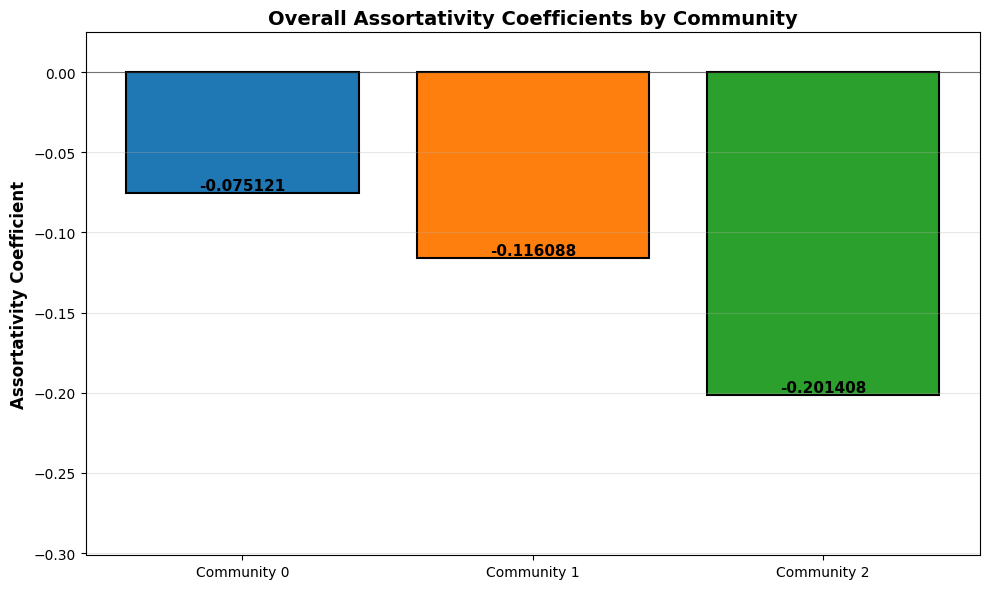

Saved: overall_assortativity_comparison.png


In [9]:
# Plot 1: Overall assortativity comparison
fig, ax = plt.subplots(figsize=(10, 6))

communities = overall_assortativity_df['community_id'].astype(int).tolist()
assortativity_values = overall_assortativity_df['assortativity'].tolist()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar([f'Community {c}' for c in communities], assortativity_values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, assortativity_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.6f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add reference lines
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax.set_ylabel('Assortativity Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Overall Assortativity Coefficients by Community', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(min(assortativity_values) - 0.1, max(assortativity_values) + 0.1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'overall_assortativity_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: overall_assortativity_comparison.png")

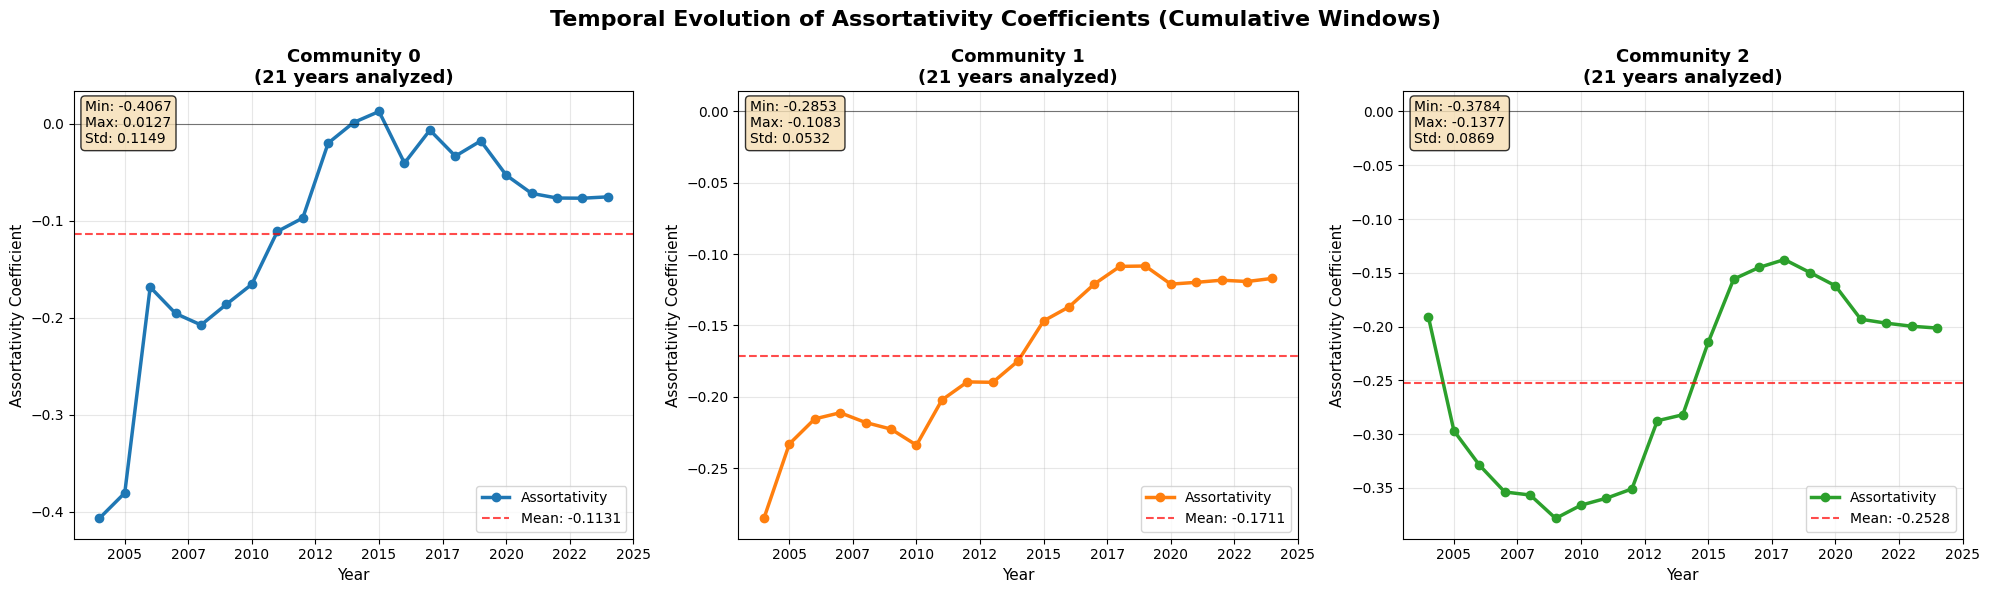

Saved: temporal_assortativity_evolution_by_community.png


In [10]:
# Plot 2: Temporal evolution of assortativity for all communities
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Temporal Evolution of Assortativity Coefficients (Cumulative Windows)', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, comm_id in enumerate(target_communities):
    ax = axes[idx]
    
    temporal_df = all_communities_temporal[comm_id]
    valid_data = temporal_df.dropna(subset=['assortativity']).copy()
    valid_data = valid_data.sort_values('year')
    
    if len(valid_data) > 0:
        # Plot assortativity evolution
        ax.plot(valid_data['year'], valid_data['assortativity'], 
               'o-', linewidth=2.5, markersize=6, color=colors[idx], label='Assortativity')
        
        # Add horizontal reference lines
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        ax.axhline(y=valid_data['assortativity'].mean(), color='red', linestyle='--', 
                  linewidth=1.5, alpha=0.7, label=f'Mean: {valid_data["assortativity"].mean():.4f}')
        
        ax.set_title(f'Community {comm_id}\n({len(valid_data)} years analyzed)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Year', fontsize=11)
        ax.set_ylabel('Assortativity Coefficient', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
        
        # Add text box with statistics
        stats_text = f'Min: {valid_data["assortativity"].min():.4f}\nMax: {valid_data["assortativity"].max():.4f}\nStd: {valid_data["assortativity"].std():.4f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'temporal_assortativity_evolution_by_community.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: temporal_assortativity_evolution_by_community.png")

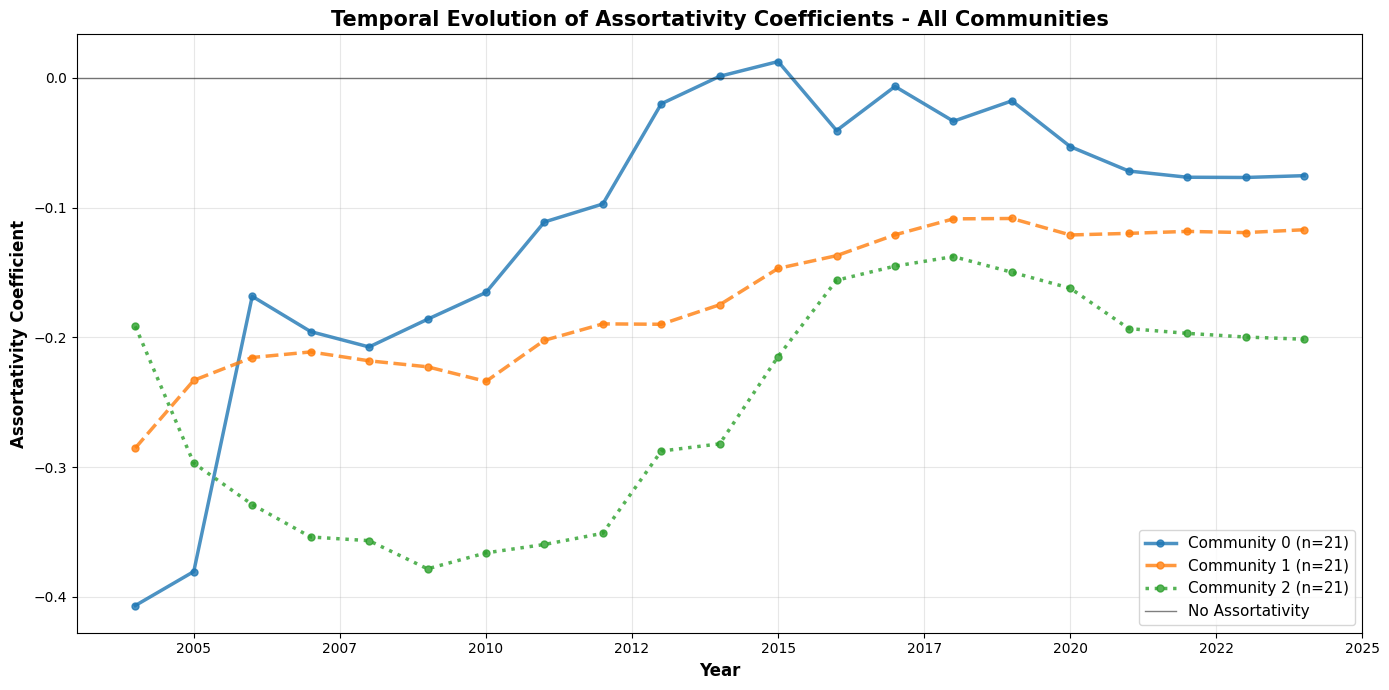

Saved: temporal_assortativity_all_communities_overlay.png


In [11]:
# Plot 3: All communities on same plot for easy comparison
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
linestyles = ['-', '--', ':']

for idx, comm_id in enumerate(target_communities):
    temporal_df = all_communities_temporal[comm_id]
    valid_data = temporal_df.dropna(subset=['assortativity']).copy()
    valid_data = valid_data.sort_values('year')
    
    if len(valid_data) > 0:
        ax.plot(valid_data['year'], valid_data['assortativity'], 
               marker='o', linewidth=2.5, markersize=5, 
               color=colors[idx], linestyle=linestyles[idx],
               label=f'Community {comm_id} (n={len(valid_data)})', alpha=0.8)

# Add reference line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='No Assortativity')

ax.set_title('Temporal Evolution of Assortativity Coefficients - All Communities', fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Assortativity Coefficient', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=11)
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'temporal_assortativity_all_communities_overlay.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: temporal_assortativity_all_communities_overlay.png")

C:\Users\joaom\AppData\Local\Temp\ipykernel_20888\3819348576.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,


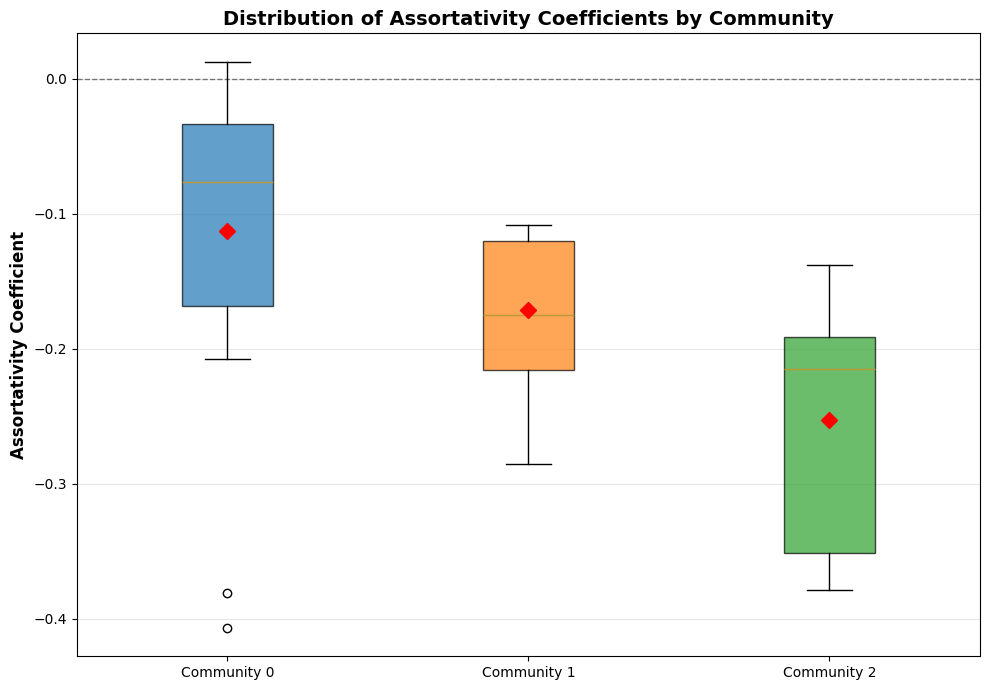

Saved: assortativity_boxplot_comparison.png


In [12]:
# Plot 4: Box plot comparison of assortativity distributions
fig, ax = plt.subplots(figsize=(10, 7))

# Prepare data for box plot
data_to_plot = []
labels = []

for comm_id in target_communities:
    valid_values = all_communities_temporal[comm_id].dropna(subset=['assortativity'])['assortativity'].values
    if len(valid_values) > 0:
        data_to_plot.append(valid_values)
        labels.append(f'Community {comm_id}')

# Create box plot
bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True,
               meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=8))

# Color the boxes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Assortativity Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Assortativity Coefficients by Community', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'assortativity_boxplot_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: assortativity_boxplot_comparison.png")

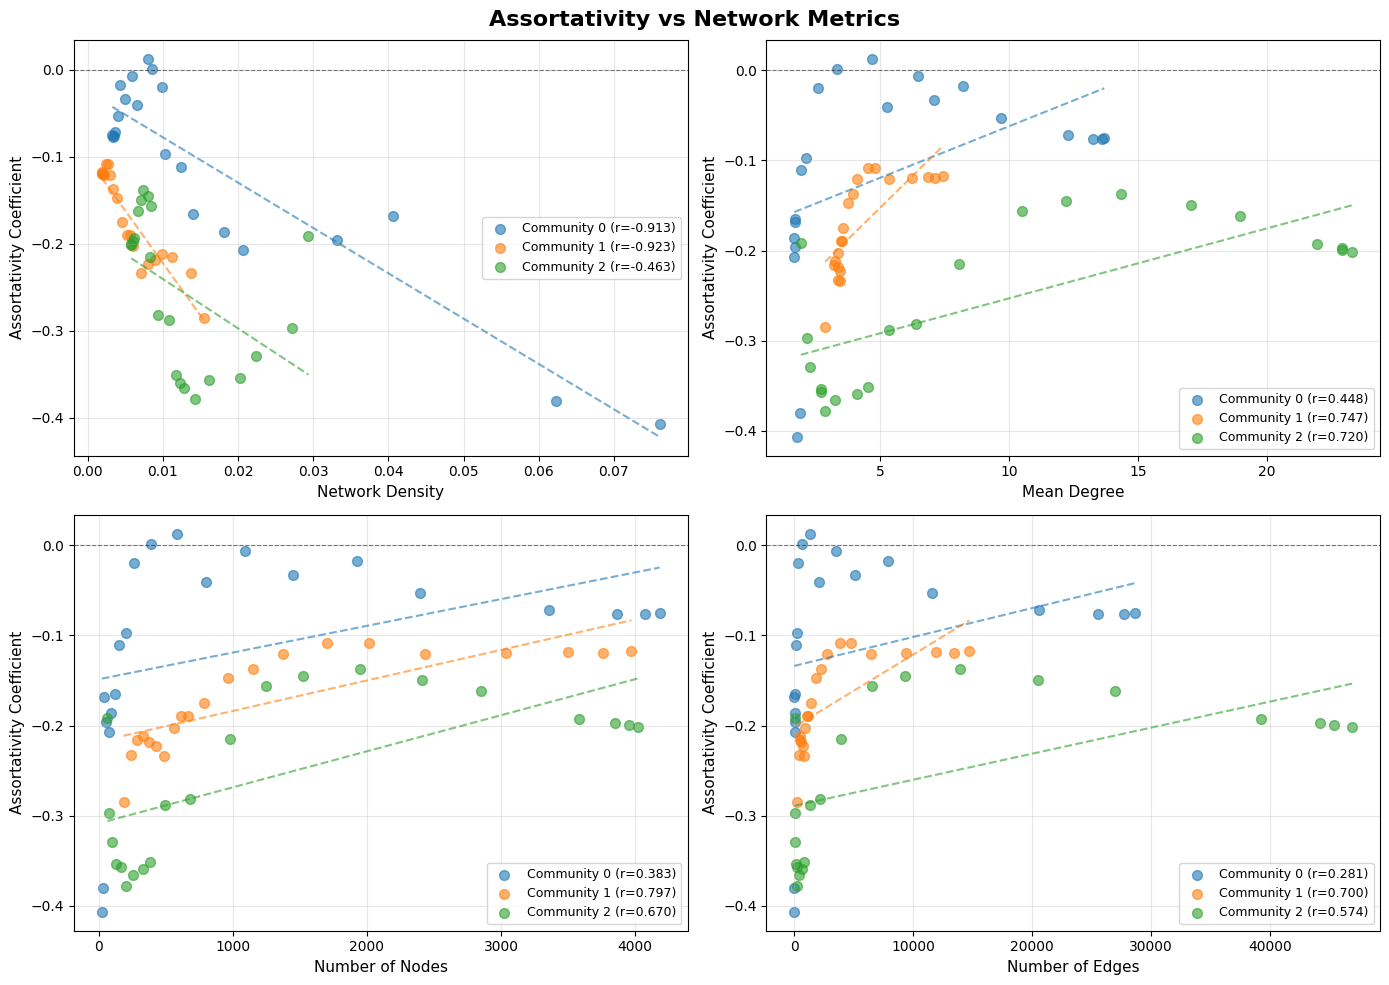

Saved: assortativity_vs_network_metrics.png


In [13]:
# Plot 5: Correlation between assortativity and network metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Assortativity vs Network Metrics', fontsize=16, fontweight='bold')

metrics = ['density', 'mean_degree', 'num_nodes', 'num_edges']
metric_labels = ['Network Density', 'Mean Degree', 'Number of Nodes', 'Number of Edges']
colors_scatter = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, (ax, metric, label) in enumerate(zip(axes.flat, metrics, metric_labels)):
    
    for comm_idx, comm_id in enumerate(target_communities):
        temporal_df = all_communities_temporal[comm_id]
        valid_data = temporal_df.dropna(subset=['assortativity']).copy()
        
        if len(valid_data) > 0 and metric in valid_data.columns:
            valid_data = valid_data.dropna(subset=[metric])
            
            # Calculate correlation
            corr = valid_data['assortativity'].corr(valid_data[metric])
            
            ax.scatter(valid_data[metric], valid_data['assortativity'], 
                      alpha=0.6, s=50, color=colors_scatter[comm_idx],
                      label=f'Community {comm_id} (r={corr:.3f})')
            
            # Add trend line
            if len(valid_data) > 2:
                z = np.polyfit(valid_data[metric], valid_data['assortativity'], 1)
                p = np.poly1d(z)
                x_trend = np.linspace(valid_data[metric].min(), valid_data[metric].max(), 100)
                ax.plot(x_trend, p(x_trend), '--', color=colors_scatter[comm_idx], alpha=0.6, linewidth=1.5)
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Assortativity Coefficient', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'assortativity_vs_network_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Saved: assortativity_vs_network_metrics.png")

## Summary and Conclusions

In [14]:
# Generate comprehensive summary report
print(f"\n{'='*80}")
print("ASSORTATIVITY ANALYSIS - COMPREHENSIVE SUMMARY")
print(f"{'='*80}")

print(f"\n1. OVERALL FINDINGS")
print("-" * 80)

for _, row in overall_assortativity_df.iterrows():
    comm_id = int(row['community_id'])
    assortativity = row['assortativity']
    
    print(f"\nCommunity {comm_id}:")
    print(f"  • Overall Assortativity: {assortativity:.6f}", end="")
    
    if assortativity > 0.1:
        print(" → ASSORTATIVE MIXING (high-degree nodes connect to other high-degree nodes)")
    elif assortativity < -0.1:
        print(" → DISASSORTATIVE MIXING (high-degree nodes connect to low-degree nodes)")
    else:
        print(" → NEUTRAL MIXING (random connection patterns)")
    
    print(f"  • Network Size: {int(row['num_nodes'])} nodes, {int(row['num_edges'])} edges")
    print(f"  • Network Density: {row['density']:.6f}")
    print(f"  • Average Degree: {row['mean_degree']:.2f} (σ={row['std_degree']:.2f})")

print(f"\n2. TEMPORAL EVOLUTION")
print("-" * 80)

for comm_id in target_communities:
    valid_data = all_communities_temporal[comm_id].dropna(subset=['assortativity'])
    
    if len(valid_data) > 0:
        print(f"\nCommunity {comm_id}:")
        print(f"  • Analysis Period: {int(valid_data['year'].min())} - {int(valid_data['year'].max())}")
        print(f"  • Mean Assortativity Over Time: {valid_data['assortativity'].mean():.6f} (σ={valid_data['assortativity'].std():.6f})")
        print(f"  • Trend: Min={valid_data['assortativity'].min():.6f}, Max={valid_data['assortativity'].max():.6f}")
        
        # Detect trend
        first_half_mean = valid_data[valid_data['year'] < valid_data['year'].median()]['assortativity'].mean()
        second_half_mean = valid_data[valid_data['year'] >= valid_data['year'].median()]['assortativity'].mean()
        trend_direction = "increasing" if second_half_mean > first_half_mean else "decreasing"
        trend_magnitude = abs(second_half_mean - first_half_mean)
        print(f"  • Trend: {trend_direction.upper()} ({trend_magnitude:+.6f})")

print(f"\n3. STATISTICAL COMPARISONS")
print("-" * 80)
print(f"\nKruskal-Wallis Test: H={h_stat:.4f}, p={p_value_kw:.6f}", end="")
if p_value_kw < 0.05:
    print(" → SIGNIFICANT DIFFERENCES between communities")
else:
    print(" → NO SIGNIFICANT DIFFERENCES between communities")

print(f"\n4. KEY INSIGHTS")
print("-" * 80)
print(f"""
• Assortativity indicates how homophilic the network is with respect to degree.
• Positive values suggest that highly-connected investors prefer to collaborate with other
  highly-connected investors, forming a "rich-club" effect.
• Negative values suggest that specialists connect with generalists, promoting diversity.
• The temporal evolution shows how these patterns change as the network grows and evolves.
""")

print(f"{'='*80}")
print("Analysis Complete")
print(f"{'='*80}")


ASSORTATIVITY ANALYSIS - COMPREHENSIVE SUMMARY

1. OVERALL FINDINGS
--------------------------------------------------------------------------------

Community 0:
  • Overall Assortativity: -0.075121 → NEUTRAL MIXING (random connection patterns)
  • Network Size: 4212 nodes, 28988 edges
  • Network Density: 0.003269
  • Average Degree: 13.76 (σ=19.77)

Community 1:
  • Overall Assortativity: -0.116088 → DISASSORTATIVE MIXING (high-degree nodes connect to low-degree nodes)
  • Network Size: 4062 nodes, 15056 edges
  • Network Density: 0.001825
  • Average Degree: 7.41 (σ=8.39)

Community 2:
  • Overall Assortativity: -0.201408 → DISASSORTATIVE MIXING (high-degree nodes connect to low-degree nodes)
  • Network Size: 4040 nodes, 47076 edges
  • Network Density: 0.005770
  • Average Degree: 23.30 (σ=40.76)

2. TEMPORAL EVOLUTION
--------------------------------------------------------------------------------

Community 0:
  • Analysis Period: 2004 - 2024
  • Mean Assortativity Over Time: 